# **Mental Health and Social Media Usage**
**Project Overview**

This project aims to investigate the relationship between social media usage, lifestyle habits, academic characteristics, and mental health among students. The dataset contains 5,000 observations and 13 variables, with Mental_Health_Score selected as the target variable for prediction.

The dataset includes demographic and academic information such as Age, Gender, Country, and Academic Level, as well as social media-related variables including Most Used Platform, Purpose of Use, Average Daily Usage Hours, and Daily Unlocks. Lifestyle-related variables include Study Hours, Physical Activity Hours, and Sleep Hours per Night. The dataset also contains a categorical Stress_Level variable, which provides an additional indicator related to students' mental well-being.

In [ ]:
import pandas as pd

In [92]:
df = pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [ ]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [93]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [94]:
df = df.drop_duplicates().reset_index(drop=True)

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0.0)

df = df[df[['Avg_Daily_Usage_Hours', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']].sum(axis=1) <= 24].reset_index(drop=True)

In [95]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(df[col].value_counts())


Gender
Gender
Male      2634
Female    2364
Name: count, dtype: int64

Country
Country
Other        1879
India         389
USA           354
Canada        230
Australia     198
             ... 
Armenia         1
Bosnia          1
Kuwait          1
Yemen           1
Syria           1
Name: count, Length: 111, dtype: int64

Academic_Level
Academic_Level
Undergraduate    3630
Graduate          918
High School       450
Name: count, dtype: int64

Most_Used_Platform
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

Purpose_Of_Use
Purpose_Of_Use
Entertainment    2551
Education        1093
Networking        793
News              561
Name: count, dtype: int64

Stress_Level
Stress_Level
Very High    1621
High         1439
Medium       1295
Low           643
Name: count, dtype: int64


In [96]:
country_counts = df["Country"].value_counts()

rare_countries = country_counts[country_counts < 70].index

df["Country"] = df["Country"].replace(
    rare_countries,
    "Other"
)

In [97]:
df["Country"].value_counts()

,count
Country,
Other,2768
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


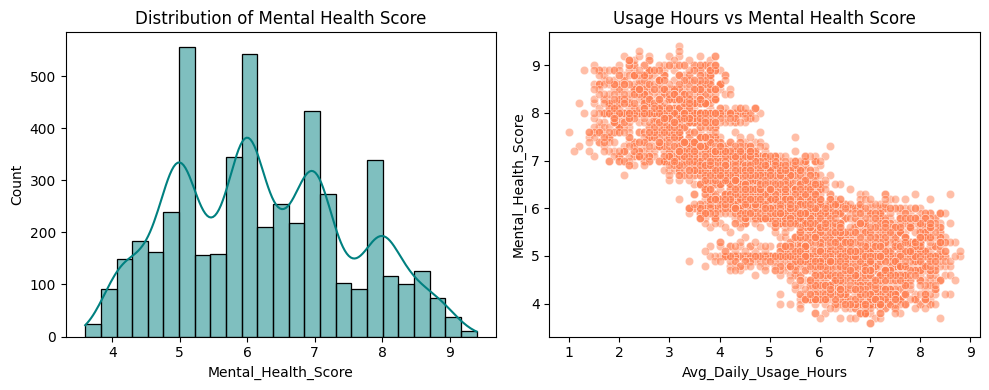

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Mental_Health_Score'], kde=True, color='teal')
plt.title("Distribution of Mental Health Score")

plt.subplot(1, 2, 2)
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df, alpha=0.5, color='coral')
plt.title("Usage Hours vs Mental Health Score")

plt.tight_layout()
plt.show()


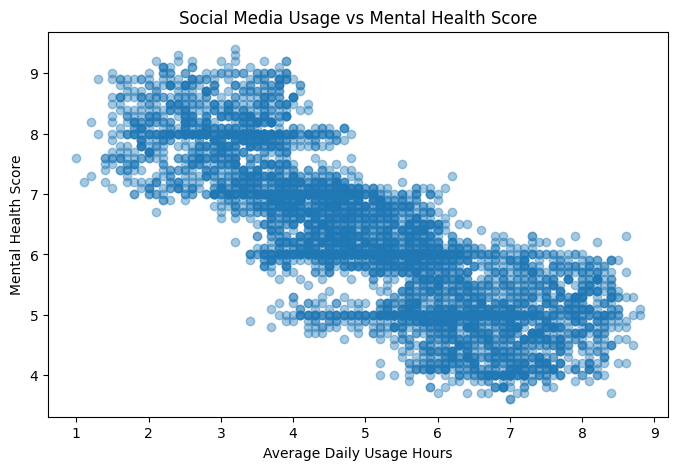

In [90]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Avg_Daily_Usage_Hours"],
    df["Mental_Health_Score"],
    alpha=0.4
)

plt.xlabel("Average Daily Usage Hours")
plt.ylabel("Mental Health Score")
plt.title("Social Media Usage vs Mental Health Score")

plt.show()

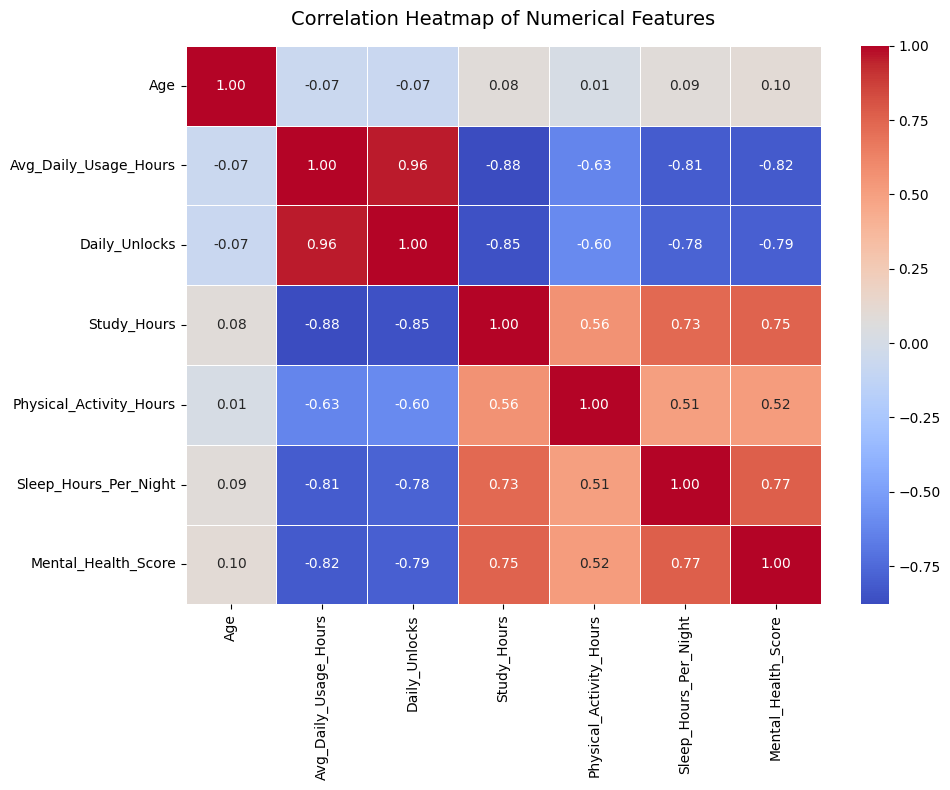

In [89]:
numeric_cols = [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Daily_Unlocks',
    'Study_Hours',
    'Physical_Activity_Hours',
    'Sleep_Hours_Per_Night',
    'Mental_Health_Score'
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# **Data Splitting And Encoding**


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

X = df.drop(columns=["Mental_Health_Score"])
y = df["Mental_Health_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

ordinal_columns = [
    "Gender",
    "Academic_Level",
    "Stress_Level"
]

nominal_columns = [
    "Country",
    "Most_Used_Platform",
    "Purpose_Of_Use"
]

numeric_columns = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Study_Hours",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night"
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["Female", "Male"],
                    ["High School", "Undergraduate", "Graduate"],
                    ["Low", "Medium", "High", "Very High"]
                ]
            ),
            ordinal_columns
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            nominal_columns
        ),

        (
            "numeric",
            StandardScaler(),
            numeric_columns
        )
    ]
)


X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Training shape:", X_train_encoded.shape)
print("Testing shape:", X_test_encoded.shape)

Training shape: (3998, 41)
Testing shape: (1000, 41)


# **Models Selection And Training**

In [ ]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Female',
                                                                              'Male'],
                                                                             ['High '
                                                                              'School',
                                                                              'Undergraduate',
                                                                              'Graduate'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]),
                                                  ['Gender', 'Academic_Level',
                                                   'Stress_Level']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Country',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use']),
                                                 ('numeric', StandardScaler(),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Study_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night'])])),
                ('model', LinearRegression())])

In [ ]:
y_train_pred_lr = lr_pipeline.predict(X_train)
y_test_pred_lr = lr_pipeline.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
mse_lr = mean_squared_error(y_test, y_test_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_test_pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("MSE :", mse_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 0.5229724312162728
MSE : 0.44718127851878775
RMSE: 0.6687161419606885
R²  : 0.7495074868362759


# Decision Tree and Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Female',
                                                                              'Male'],
                                                                             ['High '
                                                                              'School',
                                                                              'Undergraduate',
                                                                              'Graduate'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]),
                                                  ['Gender', 'Academic_Level',
                                                   'Stress_Level']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Country',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use']),
                                                 ('numeric', StandardScaler(),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Study_Hours',
                                                   'Physical_Activity_Hours',
                                                   'Sleep_Hours_Per_Night'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [ ]:
y_train_pred_rf = rf_pipeline.predict(X_train)
y_test_pred_rf = rf_pipeline.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
mse_rf = mean_squared_error(y_test, y_test_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest Regressor")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regressor
MAE : 0.32029916666666697
MSE : 0.1962236047901393
RMSE: 0.4429713363075983
R²  : 0.8900836276761477


In [ ]:
# Check Overfitting - Random Forest Regressor

y_train_pred_rf = rf_pipeline.predict(X_train)
y_test_pred_rf = rf_pipeline.predict(X_test)

train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest Regressor")
print("----------------------")
print("Train R²:", train_r2_rf)
print("Test R² :", test_r2_rf)
print("Difference:", train_r2_rf - test_r2_rf)

Random Forest Regressor
----------------------
Train R²: 0.9840812538852517
Test R² : 0.8900836276761477
Difference: 0.09399762620910401


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

extra_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

extra_model.fit(X_train, y_train)

y_pred_extra = extra_model.predict(X_test)

print("Extra Trees R²:", r2_score(y_test, y_pred_extra))

Extra Trees R²: 0.9186032229289159


In [103]:
import joblib
joblib.dump(extra_model,'XRF_Model.pkl')

['XRF_Model.pkl']

# Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    loss="squared_error"
)

gradient_boosting_model.fit(X_train_encoded, y_train)
y_pred_gb = gradient_boosting_model.predict(X_test_encoded)

gb_r2 = r2_score(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Regressor results")
print(f"R²:   {gb_r2:.4f}")
print(f"MSE:  {gb_mse:.4f}")
print(f"RMSE: {gb_rmse:.4f}")
print(f"MAE:  {gb_mae:.4f}")

Gradient Boosting Regressor results
R²:   0.8110
MSE:  0.3375
RMSE: 0.5809
MAE:  0.4463


# XGBoost

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
from sklearn.pipeline import Pipeline

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb)
])


In [85]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

param_grid = {
    "model__n_estimators": [200, 300, 500, 700, 800, 1000],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "model__max_depth": [2, 3, 4, 5, 6, 7, 8],
    "model__min_child_weight": [1, 3, 5, 7, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "model__reg_lambda": [0.5, 1, 1.5, 2, 3, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=100,
    scoring="neg_mean_squared_error",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_pipeline = random_search.best_estimator_


print("\nBest Parameters:")
print(random_search.best_params_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters:
{'model__subsample': 0.9, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.5, 'model__n_estimators': 800, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}


In [86]:
y_pred_xgb = best_pipeline.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)


print("\nFinal XGBoost Results")
print("---------------------")
print("MAE :", mae_xgb)
print("MSE :", mse_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)


Final XGBoost Results
---------------------
MAE : 0.2901085780620575
MSE : 0.1635744869323722
RMSE: 0.4044434285933846
R²  : 0.9083723172470979


# **Visualization of our best Model:**

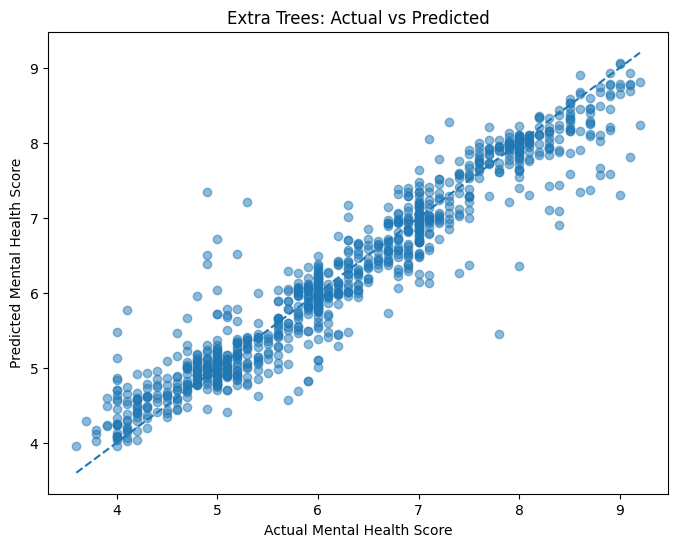

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_extra, alpha=0.5)

min_value = min(y_test.min(), y_pred_extra.min())
max_value = max(y_test.max(), y_pred_extra.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Mental Health Score")
plt.ylabel("Predicted Mental Health Score")
plt.title("Extra Trees: Actual vs Predicted")
plt.show()

In [99]:
fitted_preprocessor = extra_model.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
importances = extra_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(15))

                                 Feature  Importance
36        numeric__Avg_Daily_Usage_Hours    0.273623
2                  ordinal__Stress_Level    0.187434
40        numeric__Sleep_Hours_Per_Night    0.165486
37                numeric__Daily_Unlocks    0.134129
38                  numeric__Study_Hours    0.056283
35                          numeric__Age    0.018342
39      numeric__Physical_Activity_Hours    0.015710
13                 onehot__Country_Other    0.011711
0                        ordinal__Gender    0.011611
1                ordinal__Academic_Level    0.010011
20  onehot__Most_Used_Platform_Instagram    0.008890
32  onehot__Purpose_Of_Use_Entertainment    0.007901
16                onehot__Country_Turkey    0.007729
14                 onehot__Country_Spain    0.006560
10                 onehot__Country_Japan    0.005886


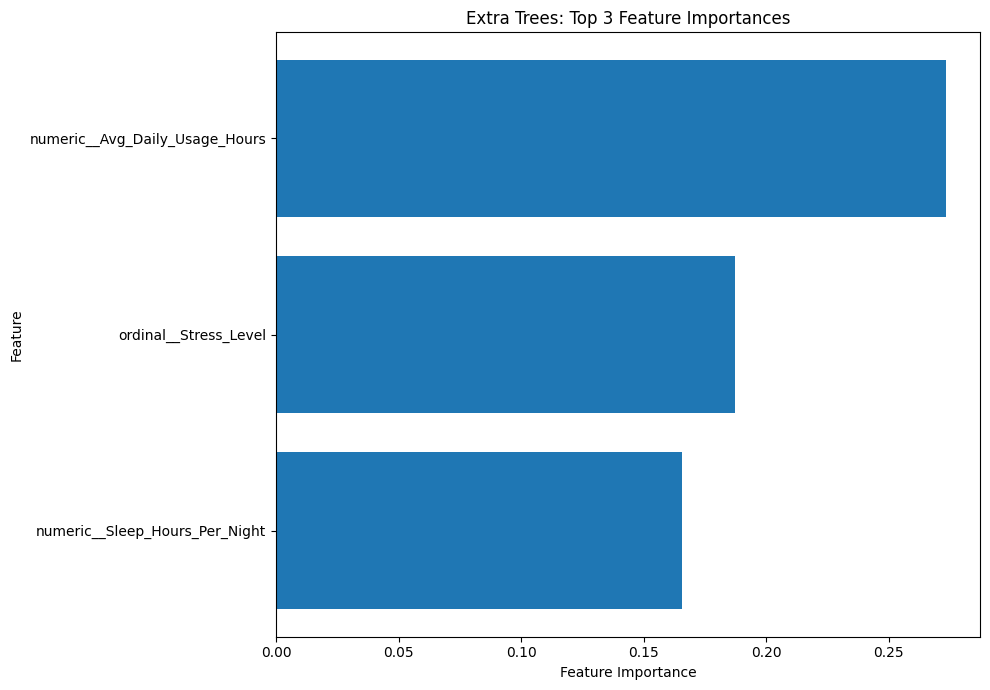

In [102]:
top_features = importance_df.head(3).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Extra Trees: Top 3 Feature Importances")
plt.tight_layout()
plt.show()